## Random Imputation

Fill Random numbers from the data itself inplace of missing values, can be applied to numerical/categorical both  

Adv:
1. Easy to Apply
2. Data Distribution remains intact, does not change after imputation
3. Shape of the distribution, variance remains same


Covariance changes, memory heavy as we need to store the original dataset to extract the values from and replace the NA in coming observations
Well suited for linear models as this does not distort the distribution regardless of NA %

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, random_state=42, test_size=0.2
)

In [6]:
x_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [7]:
x_train['AgeImputed'] = x_train['Age']
x_test['AgeImputed'] = x_test['Age']

In [66]:
x_train['AgeImputed'][x_train['AgeImputed'].isnull()] = \
    x_train['Age'].dropna().sample(x_train['AgeImputed'].isnull().sum()).values

x_test['AgeImputed'][x_test['AgeImputed'].isnull()] = \
    x_test['Age'].dropna().sample(x_test['AgeImputed'].isnull().sum()).values

In [71]:
x_train.isnull().sum()

Age           140
Fare            0
AgeImputed      0
dtype: int64

In [70]:
x_test.isnull().sum()

Age           37
Fare           0
AgeImputed     0
dtype: int64

In [68]:
x_train.sample(5)

,Age,Fare,AgeImputed
691,4.0,13.4167,4.0
771,48.0,7.8542,48.0
379,19.0,7.7750,19.0
19,NaN,7.2250,36.0
351,NaN,35.0000,31.0


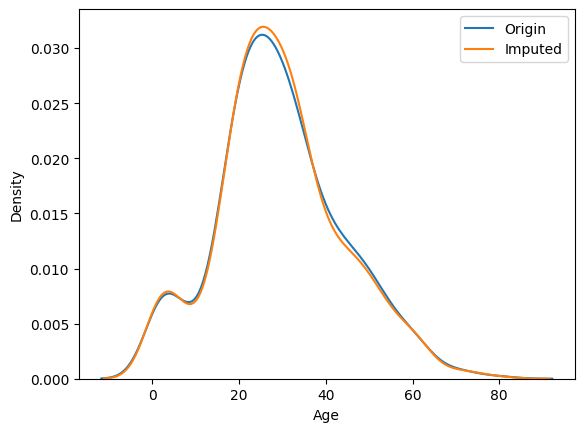

In [73]:
sns.kdeplot(x_train['Age'], label = 'Origin')
sns.kdeplot(x_train['AgeImputed'], label = 'Imputed')
plt.legend()
plt.show()

In [75]:
print(x_train['Age'].var())
print(x_train['AgeImputed'].var())

210.2517072477435
206.85932078394885


In [76]:
x_train.cov()

,Age,Fare,AgeImputed
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,48.045246
AgeImputed,210.251707,48.045246,206.859321


### Same can be one for categorical data, just the frequency before imputation and after imputation are very different its not good to do this